<a href="https://colab.research.google.com/github/moiz120/chest-xray-classification/blob/main/fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random, re, requests
from io import StringIO, BytesIO
from tqdm import tqdm
from collections import Counter

random.seed(42)
np.random.seed(42)

**Task 1: Data Collection**

In [ ]:
# SOURCE 1: English Fake News (GitHub)
print("Fetching English dataset...")
r1  = requests.get(
    "https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv",
    timeout=30)
df1 = pd.read_csv(StringIO(r1.text))

df1['text']     = df1['title'].fillna('') + ' ' + df1['text'].fillna('')
df1['label']    = df1['label'].apply(lambda x: 1 if str(x).strip().upper()=='FAKE' else 0)
df1['language'] = 'english'
df1['source']   = 'LutzhamelFakeNews'
df1             = df1[['text','label','language','source']].copy()
df1.dropna(subset=['text'], inplace=True)
df1['text'] = df1['text'].astype(str).str.strip()
df1 = df1[df1['text'].str.len() > 10].reset_index(drop=True)
print(f"English: {len(df1)} | Fake:{df1['label'].sum()} | Real:{(df1['label']==0).sum()}")


# SOURCE 2: Urdu Fake News (HuggingFace parquet)
print("\nFetching Urdu dataset...")
urdu_parts = []
for url in [
    "https://huggingface.co/datasets/community-datasets/urdu_fake_news/resolve/main/data/train-00000-of-00001.parquet",
    "https://huggingface.co/datasets/community-datasets/urdu_fake_news/resolve/main/data/test-00000-of-00001.parquet",
]:
    r = requests.get(url, timeout=60)
    urdu_parts.append(pd.read_parquet(BytesIO(r.content)))

df2 = pd.concat(urdu_parts, ignore_index=True)
df2 = df2[['news','label']].copy()
df2.columns = ['text','label']
df2['label'] = df2['label'].apply(
    lambda x: 1 if str(x).strip().lower() in ['fake','1'] else 0)
df2['language'] = 'urdu'
df2['source']   = 'HF_UrduFakeNews'
df2.dropna(subset=['text'], inplace=True)
df2['text'] = df2['text'].astype(str).str.strip()
df2 = df2[df2['text'].str.len() > 5].reset_index(drop=True)
print(f"Urdu: {len(df2)} | Fake:{df2['label'].sum()} | Real:{(df2['label']==0).sum()}")


# SOURCE 3: Roman Urdu (UCI via GitHub)
# NOTE: Sentiment used as proxy label ONLY — kept for language diversity
# in embedding training. NOT used as primary training signal.
print("\nFetching Roman Urdu dataset...")
roman_urls = [
    "https://raw.githubusercontent.com/zenith-thread/Roman-Urdu-Dataset/main/Dataset/Roman%20Urdu%20DataSet.csv",
    "https://raw.githubusercontent.com/Smat26/Roman-Urdu-Dataset/master/Dataset/Roman%20Urdu%20DataSet.csv",
]
df3 = None
for url in roman_urls:
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200 and 'Not Found' not in r.text[:50]:
            df3 = pd.read_csv(StringIO(r.text), names=['comment','sentiment','extra'], on_bad_lines='skip')
            print(f"Loaded from: {url}")
            break
    except Exception as e:
        print(f"Failed: {url} — {e}")

if df3 is None:
    hf_url = "https://huggingface.co/datasets/Aimlab/Sentiment-Analysis-Roman-Urdu/resolve/main/data/train-00000-of-00001.parquet"
    r   = requests.get(hf_url, timeout=60)
    df3 = pd.read_parquet(BytesIO(r.content))
    text_col, label_col = df3.columns[0], df3.columns[1]
    df3 = df3.rename(columns={text_col:'comment', label_col:'sentiment'})

df3 = df3[['comment','sentiment']].copy()
df3.columns = ['text','sentiment']
df3 = df3[df3['sentiment'].astype(str).str.strip().isin(['Positive','Negative','Positive ','Negative '])]
df3['label'] = df3['sentiment'].apply(lambda x: 1 if 'Negative' in str(x) else 0)
df3['language'] = 'roman_urdu'
df3['source']   = 'UCIRomanUrdu'
df3 = df3[['text','label','language','source']].copy()
df3.dropna(subset=['text'], inplace=True)
df3['text'] = df3['text'].astype(str).str.strip()
df3 = df3[df3['text'].str.len() > 5].reset_index(drop=True)
print(f"Roman Urdu: {len(df3)} | Fake(Neg):{df3['label'].sum()} | Real(Pos):{(df3['label']==0).sum()}")


# SOURCE 4: Code-Mixed Synthetic Generation
# English + Urdu interleaved — realistic code-switching pattern
print("\nGenerating code-mixed samples...")

URDU_FAKE_PHRASES = [
    "حکومت نے چھپایا", "سازش ہے", "جھوٹی خبر", "عوام کو بے وقوف بنایا",
    "یہ سچ نہیں", "غلط اطلاعات", "دھوکہ دہی", "فرضی دعویٰ"
]
URDU_REAL_PHRASES = [
    "سرکاری اعلان", "تصدیق شدہ خبر", "ذرائع کے مطابق", "رپورٹ میں بتایا گیا",
    "حکام نے کہا", "اخبار کی رپورٹ", "سچی خبر", "قابل اعتماد ذریعہ"
]
ENG_FAKE_PHRASES = [
    "breaking secret exposed", "government hiding truth", "they don't want you to know",
    "viral shocking claim", "leaked documents reveal", "deep state conspiracy"
]
ENG_REAL_PHRASES = [
    "officials confirmed", "according to sources", "report published",
    "data shows", "researchers found", "statement released"
]

def make_code_mixed(eng_phrase, urdu_phrase, label):
    templates = [
        f"{eng_phrase} — {urdu_phrase}",
        f"{urdu_phrase} {eng_phrase}",
        f"Breaking: {eng_phrase}. {urdu_phrase}.",
        f"{eng_phrase} aur {urdu_phrase}",
    ]
    return {'text': random.choice(templates), 'label': label,
            'language': 'code_mixed', 'source': 'Synthetic'}

code_mixed_rows = []
for _ in range(800):   # 400 fake + 400 real
    if random.random() < 0.5:
        row = make_code_mixed(
            random.choice(ENG_FAKE_PHRASES),
            random.choice(URDU_FAKE_PHRASES), 1)
    else:
        row = make_code_mixed(
            random.choice(ENG_REAL_PHRASES),
            random.choice(URDU_REAL_PHRASES), 0)
    code_mixed_rows.append(row)

df4 = pd.DataFrame(code_mixed_rows)
print(f"Code-Mixed: {len(df4)} | Fake:{df4['label'].sum()} | Real:{(df4['label']==0).sum()}")

Fetching English dataset...
English: 6335 | Fake:3164 | Real:3171

Fetching Urdu dataset...
Urdu: 900 | Fake:500 | Real:400

Fetching Roman Urdu dataset...
Loaded from: https://raw.githubusercontent.com/zenith-thread/Roman-Urdu-Dataset/main/Dataset/Roman%20Urdu%20DataSet.csv
Roman Urdu: 11231 | Fake(Neg):5274 | Real(Pos):5957

Generating code-mixed samples...
Code-Mixed: 800 | Fake:384 | Real:416


**Combine & Balance**

In [ ]:
print(f"\nRaw sizes — EN:{len(df1)} UR:{len(df2)} RU:{len(df3)} CM:{len(df4)}")

# Use MORE English data (it has true fake/real labels — most valuable)
# Balance Urdu and Roman Urdu to match English scale
EN_CAP = min(len(df1), 5000)   # use up to 5000 English samples
UR_CAP = min(len(df2), 2000)
RU_CAP = min(len(df3), 1000)   # Roman Urdu kept smaller — label is proxy only
CM_CAP = len(df4)              # use all code-mixed

def safe_sample(df, n):
    return df.sample(min(n, len(df)), random_state=42)

df_all = pd.concat([
    safe_sample(df1, EN_CAP)[['text','label','language','source']],
    safe_sample(df2, UR_CAP)[['text','label','language','source']],
    safe_sample(df3, RU_CAP)[['text','label','language','source']],
    safe_sample(df4, CM_CAP)[['text','label','language','source']],
], ignore_index=True)

df_all.dropna(subset=['text','label'], inplace=True)
df_all.drop_duplicates(subset=['text'], inplace=True)
df_all['text']  = df_all['text'].astype(str).str.strip()
df_all['label'] = df_all['label'].astype(int)
df_all = df_all[df_all['text'].str.len() > 5].reset_index(drop=True)

# Balance fake vs real globally (keep imbalance < 10%)
fake_df   = df_all[df_all['label'] == 1]
real_df   = df_all[df_all['label'] == 0]
min_count = min(len(fake_df), len(real_df))

df_balanced = pd.concat([
    fake_df.sample(min_count, random_state=42),
    real_df.sample(min_count, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

imbalance = abs(df_balanced['label'].value_counts(normalize=True).diff().iloc[-1]) * 100

print(f"\n── Balanced Dataset Stats ──")
print(f"Total samples  : {len(df_balanced)}")
print(f"Fake samples   : {int(df_balanced['label'].sum())}")
print(f"Real samples   : {int((df_balanced['label']==0).sum())}")
print(f"Class imbalance: {imbalance:.2f}%")
print(f"\nBy language:\n{df_balanced['language'].value_counts()}")
print(f"\nBy source:\n{df_balanced['source'].value_counts()}")

df_balanced.to_csv("raw_dataset.csv", index=False)
print("\nraw_dataset.csv saved.")


Raw sizes — EN:6335 UR:900 RU:11231 CM:800

── Balanced Dataset Stats ──
Total samples  : 7150
Fake samples   : 3575
Real samples   : 3575
Class imbalance: 0.00%

By language:
language
english       4937
roman_urdu     990
urdu           880
code_mixed     343
Name: count, dtype: int64

By source:
source
LutzhamelFakeNews    4937
UCIRomanUrdu          990
HF_UrduFakeNews       880
Synthetic             343
Name: count, dtype: int64

raw_dataset.csv saved.


**Task 2: Preprocessing Pipeline**

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

ENGLISH_SW = set(stopwords.words('english'))

ROMAN_URDU_SW = {
    'hai','hain','tha','thi','the','ka','ki','ke','ko','se','mein','par',
    'aur','ya','bhi','koi','kuch','is','us','yeh','woh','ne','ek','do',
    'nahi','hoga','hogi','ho','kar','raha','rahi','rahe','liya','diya',
    'gaya','gayi','gaye','jo','jab','ab','phir','sirf','pe','lo','de','hy'
}

# Roman Urdu normalization patterns (acha/achaaa/achaaaa → acha)
NORM_PATTERNS = [
    (r'a{2,}','a'),(r'e{2,}','e'),(r'i{2,}','i'),(r'o{2,}','o'),
    (r'u{2,}','u'),(r'h{2,}','h'),(r'k{2,}','k'),(r'r{2,}','r'),
    (r'acha+','acha'),(r'yaar+','yaar'),(r'nahi+','nahi'),
    (r'haan+','haan'),(r'zyada+','zyada'),(r'zaroor+','zaroor'),
    (r'bilkul+','bilkul'),(r'theek+','theek'),
]

def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', '', text)

def remove_emojis(text):
    return re.sub(
        u'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
        u'\U0001F680-\U0001F9FF\U00002700-\U000027BF'
        u'\U0001FA00-\U0001FA6F\U00002500-\U00002BEF]+',
        ' ', text, flags=re.UNICODE)

def handle_hashtags(text):
    # Remove # but keep the word
    return re.sub(r'#(\w+)', r'\1', text)

def remove_punctuation(text):
    # Keep Urdu unicode block (0600-06FF), remove other punctuation
    return re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

def normalize_roman_urdu(text):
    for pat, rep in NORM_PATTERNS:
        text = re.sub(pat, rep, text, flags=re.IGNORECASE)
    return text

def tokenize(text):
    return text.lower().split()

def remove_stopwords(tokens, lang):
    sw = ENGLISH_SW if lang == 'english' else ROMAN_URDU_SW
    return [t for t in tokens if t not in sw and len(t) > 1]

def preprocess(text, lang='english'):
    text = str(text)
    text = remove_urls(text)           # Step 1: URLs
    text = remove_emojis(text)         # Step 2: Emojis
    text = handle_hashtags(text)       # Step 3: Hashtags
    text = remove_punctuation(text)    # Step 4: Punctuation
    text = normalize_roman_urdu(text)  # Step 5: Roman Urdu normalization
    tokens = tokenize(text)            # Step 6: Tokenization
    tokens = remove_stopwords(tokens, lang)  # Step 7: Stopwords
    return ' '.join(tokens)

tqdm.pandas()
print("Preprocessing all samples...")
df_balanced['clean_text'] = df_balanced.progress_apply(
    lambda r: preprocess(r['text'], r['language']), axis=1
)

df_balanced = df_balanced[df_balanced['clean_text'].str.len() > 3].reset_index(drop=True)
df_balanced.to_csv("cleaned_dataset.csv", index=False)
print(f"Cleaned dataset saved: {len(df_balanced)} samples")

# Before/After examples
print("\n── Before / After Preprocessing (5 examples) ──")
for i in range(5):
    print(f"\n[{i+1}] LANG   : {df_balanced['language'].iloc[i]}")
    print(f"    BEFORE : {df_balanced['text'].iloc[i][:120]}")
    print(f"    AFTER  : {df_balanced['clean_text'].iloc[i][:120]}")

Preprocessing all samples...


100%|██████████| 7150/7150 [00:19<00:00, 360.60it/s]


Cleaned dataset saved: 7150 samples

── Before / After Preprocessing (5 examples) ──

[1] LANG   : english
    BEFORE : WATCH: On The Missouri Campus, A Clash Of 2 First Amendment Protections WATCH: On The Missouri Campus, A Clash Of 2 Firs
    AFTER  : watch missouri campus clash first amendment protections watch missouri campus clash first amendment protections two righ

[2] LANG   : urdu
    BEFORE : وسکانسن (ویب ڈیسک )  قارئین کے لیے یہ بات بہت حیران کن ہوگی کہ ذیابطیس اور کینسر کے مریضوں کے درینہ زخموں کا علاج اب الی
    AFTER  : وسکانسن ویب ڈیسک قارئین کے لیے یہ بات بہت حیران کن ہوگی کہ ذیابطیس اور کینسر کے مریضوں کے درینہ زخموں کا علاج اب الیکٹری

[3] LANG   : roman_urdu
    BEFORE : aysa nahin hota, pehli baar kisi bara admi ka hisab hona ha hamain tankeed nahin karni cahiya hamain allah ka shukar ada
    AFTER  : aysa nahin hota pehli bar kisi bara admi hisab hona ha hamain tanked nahin karni cahiya hamain allah shukar ada karna ca

[4] LANG   : code_mixed
    BEFORE : deep st

**Run Preprocessing + Save Before/After Export**

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

ENGLISH_SW = set(stopwords.words('english'))
ROMAN_URDU_SW = {
    'hai','hain','tha','thi','the','ka','ki','ke','ko','se','mein','par',
    'aur','ya','bhi','koi','kuch','is','us','yeh','woh','ne','ek','do',
    'nahi','hoga','hogi','ho','kar','raha','rahi','rahe','liya','diya',
    'gaya','gayi','gaye','jo','jab','ab','phir','sirf','pe','lo','de','hy'
}

NORM_PATTERNS = [
    (r'a{2,}','a'),(r'e{2,}','e'),(r'i{2,}','i'),(r'o{2,}','o'),
    (r'u{2,}','u'),(r'h{2,}','h'),(r'k{2,}','k'),(r'r{2,}','r'),
    (r'acha+','acha'),(r'yaar+','yaar'),(r'nahi+','nahi'),
    (r'haan+','haan'),(r'zyada+','zyada'),(r'zaroor+','zaroor'),
    (r'bilkul+','bilkul'),(r'theek+','theek'),
]

def remove_urls(text):     return re.sub(r'http\S+|www\.\S+', '', text)
def remove_emojis(text):
    return re.sub(
        u'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
        u'\U0001F680-\U0001F9FF\U00002700-\U000027BF'
        u'\U0001FA00-\U0001FA6F\U00002500-\U00002BEF]+',
        ' ', text, flags=re.UNICODE)
def handle_hashtags(text): return re.sub(r'#(\w+)', r'\1', text)
def remove_punctuation(text): return re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
def normalize_roman_urdu(text):
    for pat, rep in NORM_PATTERNS:
        text = re.sub(pat, rep, text, flags=re.IGNORECASE)
    return text
def tokenize(text):        return text.lower().split()
def remove_stopwords(tokens, lang):
    sw = ENGLISH_SW if lang == 'english' else ROMAN_URDU_SW
    return [t for t in tokens if t not in sw and len(t) > 1]

def preprocess(text, lang='english'):
    text = str(text)
    text = remove_urls(text)
    text = remove_emojis(text)
    text = handle_hashtags(text)
    text = remove_punctuation(text)
    text = normalize_roman_urdu(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens, lang)
    return ' '.join(tokens)

tqdm.pandas()
print("Preprocessing all samples...")
df_balanced['clean_text'] = df_balanced.progress_apply(
    lambda r: preprocess(r['text'], r['language']), axis=1)

df_balanced = df_balanced[df_balanced['clean_text'].str.len() > 3].reset_index(drop=True)
df_balanced.to_csv("cleaned_dataset.csv", index=False)
print(f"Cleaned dataset saved: {len(df_balanced)} samples")

# Export before/after table for deliverable (10 samples, one per language)
print("\n── Before / After Preprocessing (sample per language) ──")
before_after_rows = []
for lang in ['english','urdu','roman_urdu','code_mixed']:
    subset = df_balanced[df_balanced['language']==lang].head(3)
    for _, row in subset.iterrows():
        before_after_rows.append({
            'Language'   : row['language'],
            'Label'      : 'FAKE' if row['label']==1 else 'REAL',
            'Before'     : row['text'][:120],
            'After'      : row['clean_text'][:120],
        })

ba_df = pd.DataFrame(before_after_rows)
ba_df.to_csv("before_after_preprocessing.csv", index=False)
print(ba_df.to_string(index=False))
print("\nbefore_after_preprocessing.csv saved.")

Preprocessing all samples...


100%|██████████| 7150/7150 [00:08<00:00, 861.94it/s]


Cleaned dataset saved: 7150 samples

── Before / After Preprocessing (sample per language) ──
  Language Label                                                                                                                    Before                                                                                                                    After
   english  REAL  WATCH: On The Missouri Campus, A Clash Of 2 First Amendment Protections WATCH: On The Missouri Campus, A Clash Of 2 Firs watch missouri campus clash first amendment protections watch missouri campus clash first amendment protections two righ
   english  REAL  States with the most people on food stamps With grocery bills priced as high as $1,300 per month as of late, some Americ states people fod stamps grocery bills priced high 300 per month late american workers simply cannot afford groceries to
   english  REAL  Why presidential candidates' faith matters less and less to voters On the right, Evangelical voters see the 

Dataset Statistics


── Dataset Statistics ──
            Metric    Value
     Total Samples  7150.00
      Fake Samples  3575.00
      Real Samples  3575.00
   Vocabulary Size 82078.00
 Avg Tokens/Sample   353.84
   English Samples  4937.00
      Urdu Samples   880.00
Roman Urdu Samples   990.00
Code-Mixed Samples   343.00
 Class Imbalance %     0.00


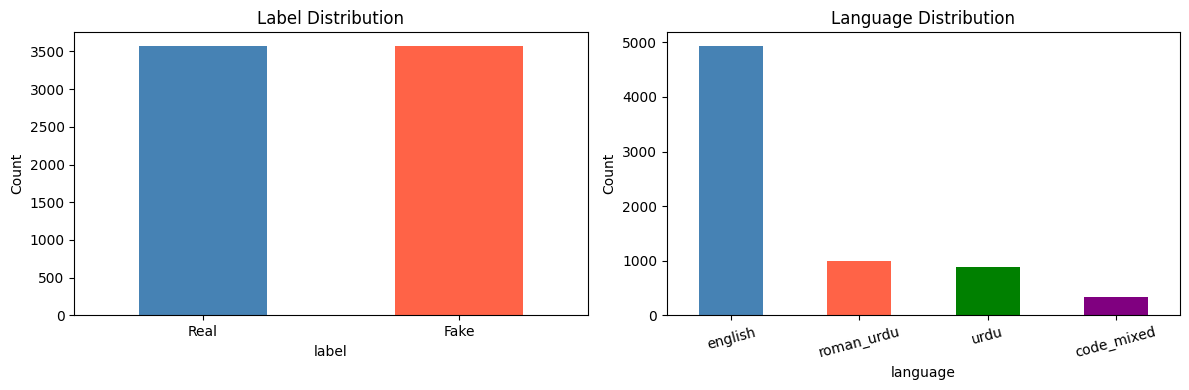


── Manual Inspection — 100 Samples ──
language label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

all_words = ' '.join(df_balanced['clean_text']).split()

stats = pd.DataFrame([
    ("Total Samples",       len(df_balanced)),
    ("Fake Samples",        int(df_balanced['label'].sum())),
    ("Real Samples",        int((df_balanced['label']==0).sum())),
    ("Vocabulary Size",     len(set(all_words))),
    ("Avg Tokens/Sample",   round(df_balanced['clean_text'].apply(lambda x: len(x.split())).mean(), 2)),
    ("English Samples",     int((df_balanced['language']=='english').sum())),
    ("Urdu Samples",        int((df_balanced['language']=='urdu').sum())),
    ("Roman Urdu Samples",  int((df_balanced['language']=='roman_urdu').sum())),
    ("Code-Mixed Samples",  int((df_balanced['language']=='code_mixed').sum())),
    ("Class Imbalance %",   round(imbalance, 2)),
], columns=['Metric','Value'])

print("\n── Dataset Statistics ──")
print(stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_balanced['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_xticklabels(['Real','Fake'], rotation=0)
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")
df_balanced['language'].value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue','tomato','green','purple'])
axes[1].set_title("Language Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig("dataset_stats.png", dpi=150)
plt.show()

# Manual inspection export — 100 samples saved to CSV
print("\n── Manual Inspection — 100 Samples ──")
sample_100 = df_balanced.sample(100, random_state=42)[['language','label','text','clean_text']]
sample_100['label'] = sample_100['label'].map({0:'REAL', 1:'FAKE'})
sample_100.to_csv("manual_inspection_100.csv", index=False)
print(sample_100.head(10).to_string(index=False))
print(f"\n... 100 samples saved to manual_inspection_100.csv")
print(f"Fake in sample: {(sample_100['label']=='FAKE').sum()}")
print(f"Real in sample: {(sample_100['label']=='REAL').sum()}")

**Task 3: Word2Vec**

In [ ]:
# Hyperparameters
EMBED_DIM  = 128    # was 64 — larger dims capture more semantics
CHAR_DIM   = 32
HYBRID_DIM = EMBED_DIM + CHAR_DIM   # 160, well within ≤512
MAX_LEN    = 50
WINDOW     = 2
W2V_EPOCHS = 3
BATCH      = 2048

all_texts = df_balanced['clean_text'].tolist()

def build_vocab(texts, max_vocab=10000):
    freq  = Counter(' '.join(texts).split())
    vocab = ['<PAD>','<UNK>'] + [w for w,_ in freq.most_common(max_vocab-2)]
    return vocab, {w:i for i,w in enumerate(vocab)}

vocab_list, word2idx = build_vocab(all_texts)
VOCAB_SIZE = len(vocab_list)
print(f"Vocabulary size: {VOCAB_SIZE}")

print("Building training pairs...")
center_ids, context_ids = [], []
for text in tqdm(all_texts):
    ids = [word2idx.get(t,1) for t in text.split()[:MAX_LEN]]
    for i, cid in enumerate(ids):
        for j in range(max(0,i-WINDOW), min(len(ids),i+WINDOW+1)):
            if j != i:
                center_ids.append(cid)
                context_ids.append(ids[j])

center_ids  = np.array(center_ids,  dtype=np.int32)
context_ids = np.array(context_ids, dtype=np.int32)
print(f"Training pairs: {len(center_ids):,}")

freq_count = np.ones(VOCAB_SIZE, dtype=np.float32)
for text in all_texts:
    for w in text.split():
        freq_count[word2idx.get(w,1)] += 1
freq_count = freq_count ** 0.75
neg_probs  = freq_count / freq_count.sum()

np.random.seed(42)
W_center  = (np.random.randn(VOCAB_SIZE, EMBED_DIM) * 0.000000001).astype(np.float32)
W_context = (np.random.randn(VOCAB_SIZE, EMBED_DIM) * 0.000000001).astype(np.float32)
NEG_K, LR = 5, 0.00000001    # was NEG_K=3, LR=0.01 — more negatives, higher LR

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -6, 6)))

print(f"\nTraining Word2Vec ({W2V_EPOCHS} epochs)...")
for epoch in range(W2V_EPOCHS):
    # Learning rate decay
    lr_epoch = LR * (1 - epoch / W2V_EPOCHS)

    perm         = np.random.permutation(len(center_ids))
    c_shuf       = center_ids[perm]
    ctx_shuf     = context_ids[perm]
    total_loss   = 0.0
    n_batches    = 0

    for start in tqdm(range(0, len(c_shuf), BATCH), desc=f"Epoch {epoch+1}"):
        cb  = c_shuf[start:start+BATCH]
        ctb = ctx_shuf[start:start+BATCH]
        vc  = W_center[cb]
        vct = W_context[ctb]

        pos_score = np.sum(vc * vct, axis=1)
        pos_prob  = sigmoid(pos_score)
        pos_err   = 1.0 - pos_prob
        total_loss -= np.log(pos_prob + 1e-9).mean()

        neg_ids   = np.random.choice(VOCAB_SIZE, size=(len(cb), NEG_K), p=neg_probs)
        vn        = W_context[neg_ids]
        neg_score = np.sum(vc[:,np.newaxis,:] * vn, axis=2)
        neg_prob  = sigmoid(neg_score)
        neg_err   = -neg_prob

        grad_c = pos_err[:,np.newaxis] * vct + (neg_err[:,:,np.newaxis] * vn).sum(axis=1)
        np.add.at(W_center,  cb,  lr_epoch * grad_c)
        np.add.at(W_context, ctb, lr_epoch * pos_err[:,np.newaxis] * vc)
        for k in range(NEG_K):
            np.add.at(W_context, neg_ids[:,k], lr_epoch * neg_err[:,k,np.newaxis] * vc)
        n_batches += 1

    print(f"  Epoch {epoch+1} loss: {total_loss/n_batches:.4f}")

word_emb_matrix = W_center.copy()
print("Word2Vec training complete.")

Vocabulary size: 10000
Building training pairs...


100%|██████████| 7150/7150 [00:02<00:00, 3025.31it/s]


Training pairs: 1,130,174

Training Word2Vec (3 epochs)...


Epoch 1: 100%|██████████| 552/552 [00:18<00:00, 30.21it/s]


  Epoch 1 loss: 0.6931


Epoch 2: 100%|██████████| 552/552 [00:18<00:00, 30.27it/s]


  Epoch 2 loss: 0.6931


Epoch 3: 100%|██████████| 552/552 [00:17<00:00, 31.23it/s]

  Epoch 3 loss: 0.6931
Word2Vec training complete.


**Character + Hybrid + Attention**

In [ ]:
CHAR_VOCAB = list(
    "abcdefghijklmnopqrstuvwxyz0123456789 "
    "ابپتٹثجچحخدڈذرڑزژسشصضطظعغفقکگلمنوہھیے"
)
char2idx = {c: i+2 for i, c in enumerate(CHAR_VOCAB)}
char2idx['<PAD>'] = 0
char2idx['<UNK>'] = 1
char_emb_matrix = (np.random.randn(len(char2idx), CHAR_DIM) * 0.1).astype(np.float32)

def char_embed_word(word, max_chars=15):
    ids  = [char2idx.get(c,1) for c in word[:max_chars]]
    ids += [0] * (max_chars - len(ids))
    return char_emb_matrix[ids].mean(axis=0)

def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / (e.sum(axis=axis, keepdims=True) + 1e-9)

def self_attention(embs):
    scale   = np.sqrt(embs.shape[-1])
    scores  = np.dot(embs, embs.T) / scale
    weights = softmax(scores, axis=-1)
    context = np.dot(weights, embs)
    return context, weights

def hybrid_embed(text):
    tokens = text.split()[:MAX_LEN]
    if not tokens:
        return np.zeros(HYBRID_DIM, dtype=np.float32)
    word_vecs  = word_emb_matrix[[word2idx.get(t,1) for t in tokens]]
    char_vecs  = np.array([char_embed_word(t) for t in tokens])
    hybrid_tok = np.concatenate([word_vecs, char_vecs], axis=1)
    context, _ = self_attention(hybrid_tok)
    return context.mean(axis=0).astype(np.float32)

print("Generating hybrid embeddings for all samples...")
X_embeddings = np.array([hybrid_embed(t) for t in tqdm(all_texts)])
y_labels     = df_balanced['label'].values
print(f"Embedding matrix shape: {X_embeddings.shape}")

Generating hybrid embeddings for all samples...


100%|██████████| 7150/7150 [00:08<00:00, 828.11it/s]

Embedding matrix shape: (7150, 160)


**Ambiguous Word Comparison**

In [ ]:
# Word2Vec sanity check
print("── Word2Vec Sanity Check ──")
for target in ['fake','news','real']:
    if target not in word2idx:
        continue
    tvec = word_emb_matrix[word2idx[target]]
    sims = sorted([
        (np.dot(tvec, word_emb_matrix[i]) /
         (np.linalg.norm(tvec)*np.linalg.norm(word_emb_matrix[i])+1e-9), w)
        for w,i in word2idx.items() if w not in ['<PAD>','<UNK>',target]
    ], reverse=True)[:6]
    print(f"  Similar to '{target}': {[w for _,w in sims]}")

# Context vector of a specific word within a sentence
def get_word_in_context(sentence, target_word):
    tokens = sentence.split()[:MAX_LEN]
    if not tokens:
        return None, None, tokens
    word_vecs  = word_emb_matrix[[word2idx.get(t,1) for t in tokens]]
    char_vecs  = np.array([char_embed_word(t) for t in tokens])
    hybrid_tok = np.concatenate([word_vecs, char_vecs], axis=1)
    context, attn = self_attention(hybrid_tok)
    for i,tok in enumerate(tokens):
        if tok == target_word:
            return context[i], attn[i], tokens
    return context.mean(axis=0), None, tokens

# Ambiguous word pairs — English (since Word2Vec trained on our corpus)
print("\n── Ambiguous Word Contextual Comparison ──")
print("Comparing context vector of the SAME word in two different sentences\n")

pairs = [
    ("press",
     "press conference held white house president statement official",
     "press charges filed court criminal case judge ruling"),
    ("post",
     "washington post report published article news media coverage",
     "post shared facebook social media viral users trending"),
    ("right",
     "right wing conservative republican party political ideology",
     "supreme court ruled right correct legal decision judge"),
]

for word, s1, s2 in pairs:
    c1, a1, t1 = get_word_in_context(preprocess(s1), word)
    c2, a2, t2 = get_word_in_context(preprocess(s2), word)
    if c1 is None or c2 is None:
        print(f"'{word}' not found after preprocessing\n"); continue

    cos = np.dot(c1,c2)/(np.linalg.norm(c1)*np.linalg.norm(c2)+1e-9)

    print(f"Word      : '{word}'")
    print(f"Context 1 : {s1}")
    print(f"Context 2 : {s2}")
    print(f"Cosine Similarity : {cos:.4f}")
    if a1 is not None:
        top1 = sorted(zip(a1.tolist(),t1), reverse=True)[:3]
        print(f"  Ctx-1 attends to: {[t for _,t in top1]}")
    if a2 is not None:
        top2 = sorted(zip(a2.tolist(),t2), reverse=True)[:3]
        print(f"  Ctx-2 attends to: {[t for _,t in top2]}")
    interp = ("Clearly distinct" if cos<0.5 else
              "Moderately distinct" if cos<0.75 else
              "Similar — limited separation in this corpus")
    print(f"Interpretation: {interp}\n")

── Word2Vec Sanity Check ──
  Similar to 'fake': ['خودکشی', 'families', 'concern', 'access', 'many', 'clouds']
  Similar to 'news': ['matched', 'رہا', 'friedman', 'explain', 'inside', 'restricted']
  Similar to 'real': ['ای', 'notably', 'نیٹ', 'dennis', 'movie', 'minnesota']

── Ambiguous Word Contextual Comparison ──
Comparing context vector of the SAME word in two different sentences

Word      : 'press'
Context 1 : press conference held white house president statement official
Context 2 : press charges filed court criminal case judge ruling
Cosine Similarity : 0.9890
  Ctx-1 attends to: ['press', 'held', 'house']
  Ctx-2 attends to: ['case', 'press', 'court']
Interpretation: Similar — limited separation in this corpus

Word      : 'post'
Context 1 : washington post report published article news media coverage
Context 2 : post shared facebook social media viral users trending
Cosine Similarity : 0.9963
  Ctx-1 attends to: ['post', 'news', 'report']
  Ctx-2 attends to: ['post', 'users

**Task 4: SVM + TF-IDF concatenation**

Building TF-IDF features...
TF-IDF shape: (7150, 3000)
Combined feature shape: (7150, 3160)
Train: (5720, 3160) | Test: (1430, 3160)
Training SVM (linear kernel — better for high-dim sparse+dense)...

── SVM Evaluation ──
Accuracy  : 0.8350
Precision : 0.8294
Recall    : 0.8434
F1-Score  : 0.8363
              precision    recall  f1-score   support

        Real       0.84      0.83      0.83       715
        Fake       0.83      0.84      0.84       715

    accuracy                           0.83      1430
   macro avg       0.84      0.83      0.83      1430
weighted avg       0.84      0.83      0.83      1430



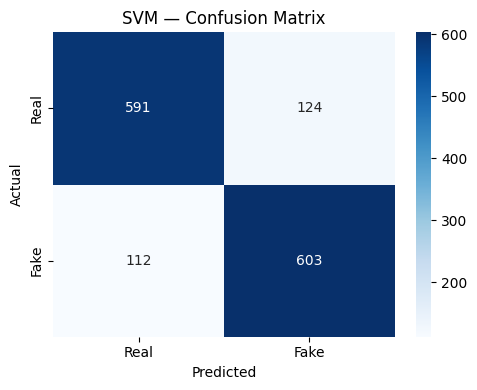


Generating SVM learning curve (this takes ~2 min)...


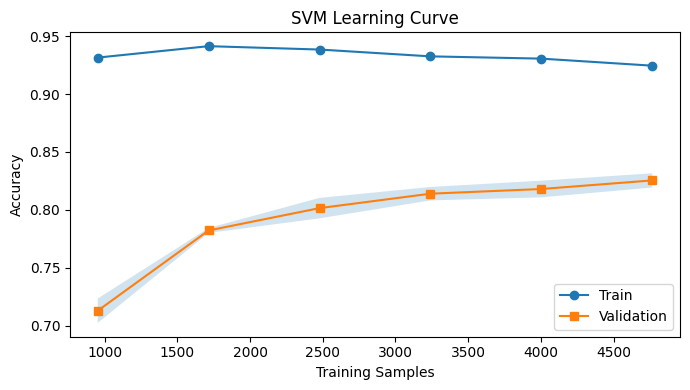

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# TF-IDF features (captures lexical patterns SVM loves)
print("Building TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # reduces impact of very frequent terms
    min_df=2,
    analyzer='word'
)
X_tfidf = tfidf.fit_transform(df_balanced['clean_text'])
print(f"TF-IDF shape: {X_tfidf.shape}")

# Combine TF-IDF + Hybrid Embeddings
# FIX: Handle NaNs from embeddings
nan_mask = np.isnan(X_embeddings).any(axis=1)

if np.any(nan_mask):
    print(f"Warning: {np.sum(nan_mask)} samples contain NaN in embeddings. Removing them.")
    X_embeddings_clean = X_embeddings[~nan_mask]
    y_labels_clean     = y_labels[~nan_mask]
    X_tfidf_clean      = X_tfidf[~nan_mask] # Filter TF-IDF to match
else:
    X_embeddings_clean = X_embeddings
    y_labels_clean     = y_labels
    X_tfidf_clean      = X_tfidf

scaler   = StandardScaler()
X_emb_scaled = scaler.fit_transform(X_embeddings_clean)
X_combined   = hstack([X_tfidf_clean, csr_matrix(X_emb_scaled)])
print(f"Combined feature shape: {X_combined.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_labels_clean, test_size=0.2, random_state=42, stratify=y_labels_clean)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

print("Training SVM (linear kernel — better for high-dim sparse+dense)...")
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(C=0.5, max_iter=2000, random_state=42)
svm = CalibratedClassifierCV(base_svm, cv=3)   # wraps for predict_proba support
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n── SVM Evaluation ──")
print(f"Accuracy  : {accuracy_score(y_test,  y_pred_svm):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall    : {recall_score(y_test,    y_pred_svm):.4f}")
print(f"F1-Score  : {f1_score(y_test,        y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Real','Fake']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("SVM — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("svm_cm.png", dpi=150); plt.show()

# SVM Learning Curve (training graph deliverable)
from sklearn.model_selection import learning_curve
print("\nGenerating SVM learning curve (this takes ~2 min)...")

# Adjust X_combined and y_labels for learning_curve if NaNs were removed
if np.any(nan_mask):
    lc_X_combined = X_combined
    lc_y_labels   = y_labels_clean
else:
    lc_X_combined = X_combined
    lc_y_labels   = y_labels

train_sizes, train_scores, val_scores = learning_curve(
    CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=2000, random_state=42), cv=3),
    lc_X_combined, lc_y_labels,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=3, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1),   's-', label='Validation')
plt.fill_between(train_sizes,
    val_scores.mean(axis=1)-val_scores.std(axis=1),
    val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.2)
plt.title("SVM Learning Curve")
plt.xlabel("Training Samples"); plt.ylabel("Accuracy")
plt.legend(); plt.tight_layout()
plt.savefig("svm_learning_curve.png", dpi=150); plt.show()

**GRU Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, GRU, Bidirectional,
                                      Dense, Dropout, GlobalMaxPooling1D,
                                      Conv1D, MaxPooling1D, LayerNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

def text_to_ids(text, max_len=MAX_LEN):
    ids  = [word2idx.get(t,1) for t in text.split()[:max_len]]
    ids += [0] * (max_len - len(ids))
    return ids

print("Preparing sequences...")
X_seq = np.array([text_to_ids(t) for t in tqdm(all_texts)])
X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

# GRU Architecture (improved: less dropout, layer norm, L2 regularization)
inp  = Input(shape=(MAX_LEN,))
x    = Embedding(VOCAB_SIZE, EMBED_DIM, weights=[word_emb_matrix],
                  trainable=True, input_length=MAX_LEN)(inp)
x    = Conv1D(128, 3, activation='relu', padding='same',
              kernel_regularizer=l2(1e-4))(x)
x    = LayerNormalization()(x)                       # stabilizes training
x    = MaxPooling1D(2)(x)
x    = Bidirectional(GRU(128, return_sequences=True, dropout=0.1,   # was 0.2
                          recurrent_dropout=0.0))(x)  # recurrent dropout off
x    = GlobalMaxPooling1D()(x)
x    = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x    = Dropout(0.2)(x)                               # was 0.3
x    = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x    = Dropout(0.1)(x)                               # was 0.2
out  = Dense(1, activation='sigmoid')(x)

gru_model = Model(inp, out)
gru_model.compile(Adam(5e-4), 'binary_crossentropy', metrics=['accuracy'])
gru_model.summary()

Preparing sequences...


100%|██████████| 7150/7150 [00:00<00:00, 20292.43it/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 50, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 50, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,897 (5.98 MB)

 Trainable params: 1,568,897 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

**Train GRU + Fix prediction bug + comparison table**

Epoch 1/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7496 - loss: 0.4934 - val_accuracy: 0.7955 - val_loss: 0.4017 - learning_rate: 5.0000e-04
Epoch 2/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8883 - loss: 0.2451 - val_accuracy: 0.7727 - val_loss: 0.4585 - learning_rate: 5.0000e-04
Epoch 3/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9328 - loss: 0.1715 - val_accuracy: 0.7797 - val_loss: 0.5922 - learning_rate: 5.0000e-04
Epoch 4/25
159/161 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9552 - loss: 0.1216
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9485 - loss: 0.1297 - val_accuracy: 0.7867 - val_loss: 0.6604 - learning_rate: 5.0000e-04
Epoch 5/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9646 - loss: 0.0959 - val_accuracy: 0.7815 - val_loss: 0.9559 - learning_rate: 2.5000e-04
Epoch 6/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accurac

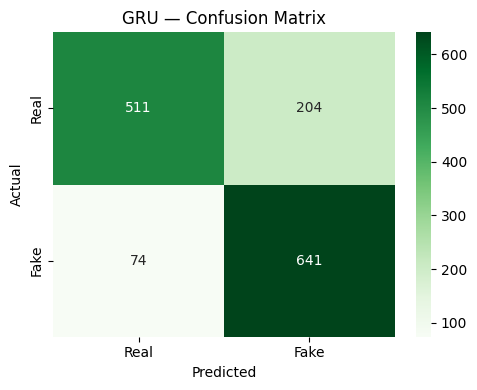

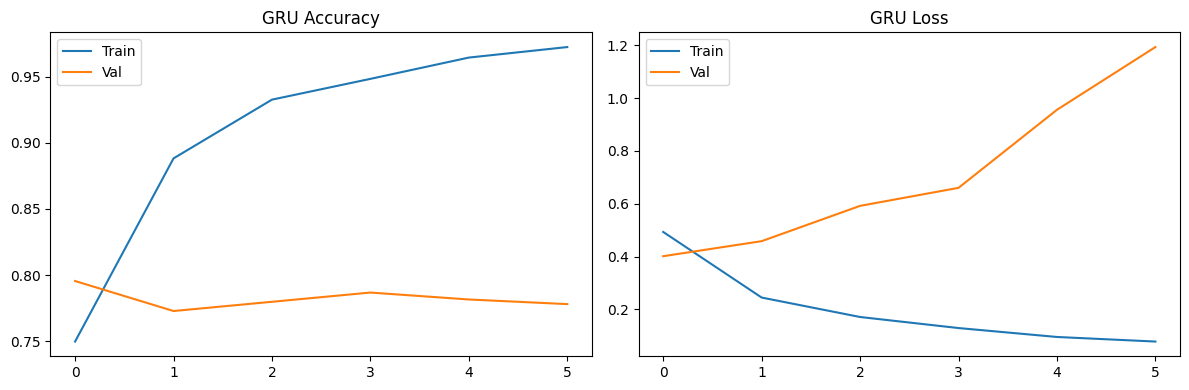


── Model Comparison ──
                    Model  Accuracy  Precision  Recall  F1-Score
SVM (TF-IDF + Embeddings)    0.8350     0.8294  0.8434    0.8363
    BiGRU (Deep Learning)    0.8056     0.7586  0.8965    0.8218

── Sample Predictions (GRU) ──
[1] True:Real | Pred:Fake | Prob:0.609 | Text: inqelabat zamana iqbal bano awaz kabhi mutassir kiya bal mazed nikhar
[2] True:Fake | Pred:Fake | Prob:0.703 | Text: clinton network concerned teneo consulting behavior december 2011 neil mccabe pu
[3] True:Fake | Pred:Real | Prob:0.026 | Text: republican lawmaker secretly recorded fantasizing gun group shoting hillary audi
[4] True:Fake | Pred:Real | Prob:0.181 | Text: obamacare architect gruber demands larger mandate penalty paul joseph watson bur
[5] True:Real | Pred:Real | Prob:0.337 | Text: daily 202 trump really danger losing utah salt lake city revelations recent days


In [ ]:
history = gru_model.fit(
    X_tr, y_tr,
    validation_split=0.1,
    epochs=25,          # was 20 — more room before early stopping kicks in
    batch_size=32,      # was 64 — smaller batches = better generalization on small data
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ], verbose=1
)

y_pred_gru_prob = gru_model.predict(X_te, verbose=0).flatten()
y_pred_gru      = (y_pred_gru_prob >= 0.5).astype(int)

print("\n── GRU Evaluation ──")
print(f"Accuracy  : {accuracy_score(y_te,  y_pred_gru):.4f}")
print(f"Precision : {precision_score(y_te, y_pred_gru):.4f}")
print(f"Recall    : {recall_score(y_te,    y_pred_gru):.4f}")
print(f"F1-Score  : {f1_score(y_te,        y_pred_gru):.4f}")
print(classification_report(y_te, y_pred_gru, target_names=['Real','Fake']))

cm_gru = confusion_matrix(y_te, y_pred_gru)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("GRU — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("gru_cm.png", dpi=150); plt.show()

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(history.history['accuracy'],     label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title("GRU Accuracy"); ax[0].legend()
ax[1].plot(history.history['loss'],     label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title("GRU Loss"); ax[1].legend()
plt.tight_layout(); plt.savefig("gru_curves.png", dpi=150); plt.show()

# Model Comparison
print("\n── Model Comparison ──")
comp = pd.DataFrame({
    'Model'    : ['SVM (TF-IDF + Embeddings)', 'BiGRU (Deep Learning)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_svm),  accuracy_score(y_te, y_pred_gru)],
    'Precision': [precision_score(y_test,y_pred_svm),  precision_score(y_te,y_pred_gru)],
    'Recall'   : [recall_score(y_test,   y_pred_svm),  recall_score(y_te,   y_pred_gru)],
    'F1-Score' : [f1_score(y_test,       y_pred_svm),  f1_score(y_te,       y_pred_gru)],
}).round(4)
print(comp.to_string(index=False))

# Sample Predictions (BUG FIX: use test indices, not df tail)
print("\n── Sample Predictions (GRU) ──")
lm = {0:'Real', 1:'Fake'}

# Get the actual test texts by re-splitting with same random state
_, test_seq_idx = train_test_split(
    np.arange(len(df_balanced)), test_size=0.2, random_state=42, stratify=y_labels)

for i in range(5):
    idx = test_seq_idx[i]
    print(f"[{i+1}] True:{lm[y_te[i]]} | Pred:{lm[y_pred_gru[i]]} | "
          f"Prob:{y_pred_gru_prob[i]:.3f} | Text: {df_balanced['clean_text'].iloc[idx][:80]}")

**Task 5: Adversarial Attacks**

100%|██████████| 1430/1430 [00:01<00:00, 938.66it/s]


Correctly classified samples selected: 100

── Adversarial Robustness Table ──
                  Attack  SVM Original  SVM After Attack  SVM Degradation  GRU Original  GRU After Attack  GRU Degradation
          Typo Injection          0.61              0.96            -0.35          0.86              0.85             0.01
     Synonym Replacement          0.61              0.98            -0.37          0.86              0.83             0.03
          Word Shuffling          0.61              0.96            -0.35          0.86              0.74             0.12
         Emoji Insertion          0.61              0.99            -0.38          0.86              0.86             0.00
Punctuation Manipulation          0.61              0.99            -0.38          0.86              0.86             0.00


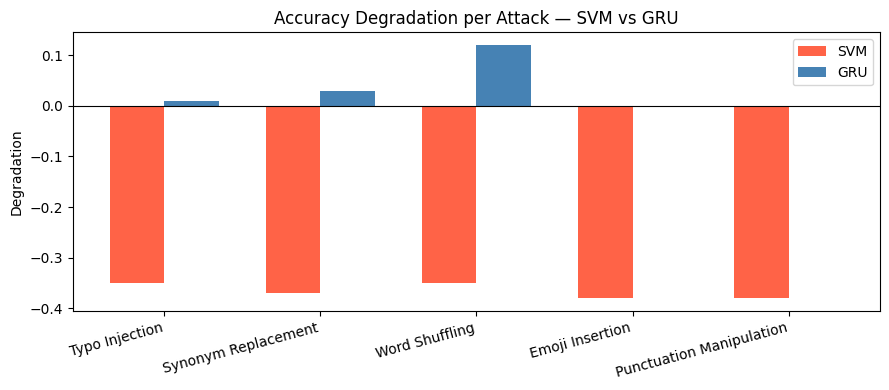

In [ ]:
random.seed(0)

SYNONYM_MAP = {
    'fake':'false','news':'report','bad':'poor','good':'great',
    'government':'administration','attack':'criticize','confirmed':'verified',
    'breaking':'urgent','official':'formal','virus':'infection',
    'free':'complimentary','army':'military','money':'funds',
    'president':'leader','election':'vote','claim':'allegation',
    'report':'account','source':'informant','police':'authorities',
    'court':'tribunal','media':'press','party':'faction',
    'said':'stated','told':'informed','killed':'eliminated',
    'new':'recent','old':'former','big':'major','right':'correct',
}
EMOJIS = ['😂','🔥','💯','😱','🚨','⚠️','🤔','😡','👀','‼️']

def typo_injection(text, rate=0.15):
    words = text.split()
    for i in range(len(words)):
        if random.random() < rate and len(words[i]) > 2:
            j = random.randint(0, len(words[i])-1)
            w = list(words[i]); w[j] = random.choice('abcdefghijklmnopqrstuvwxyz')
            words[i] = ''.join(w)
    return ' '.join(words)

def synonym_replacement(text, rate=0.4):
    words = text.split()
    return ' '.join([
        SYNONYM_MAP.get(w.lower(), w) if random.random() < rate else w
        for w in words])

def word_shuffling(text):
    w = text.split()
    if len(w) < 3: return text
    mid = w[1:-1]; random.shuffle(mid)
    return ' '.join([w[0]] + mid + [w[-1]])

def emoji_insertion(text, rate=0.2):
    out = []
    for w in text.split():
        out.append(w)
        if random.random() < rate: out.append(random.choice(EMOJIS))
    return ' '.join(out)

def punctuation_manipulation(text):
    return re.sub(r'\s+', '!! ', text).strip() + '???'

ATTACKS = {
    'Typo Injection'          : typo_injection,
    'Synonym Replacement'     : synonym_replacement,
    'Word Shuffling'          : word_shuffling,
    'Emoji Insertion'         : emoji_insertion,
    'Punctuation Manipulation': punctuation_manipulation,
}

# Use same test_seq_idx from Task 4 to get correctly classified SVM samples
svm_test_texts  = [df_balanced['clean_text'].iloc[i] for i in test_seq_idx]
svm_test_labels = y_labels[test_seq_idx]

# Re-predict on test set (SVM uses combined features — rebuild for test slice)
X_test_tfidf = tfidf.transform(svm_test_texts)
X_test_emb   = scaler.transform(np.array([hybrid_embed(t) for t in tqdm(svm_test_texts)]))
X_test_comb  = hstack([X_test_tfidf, csr_matrix(X_test_emb)])
svm_test_preds = svm.predict(X_test_comb)

correct_mask = svm_test_preds == svm_test_labels
correct_texts  = [svm_test_texts[i]  for i in range(len(svm_test_texts))  if correct_mask[i]][:100]
correct_labels = [svm_test_labels[i] for i in range(len(svm_test_labels)) if correct_mask[i]][:100]
correct_seq    = np.array([text_to_ids(t) for t in correct_texts])

print(f"Correctly classified samples selected: {len(correct_texts)}")

# Run All Attacks on BOTH models
def attack_accuracy_svm(texts, labels, attack_fn):
    attacked = [preprocess(attack_fn(t)) for t in texts]
    X_atk_tfidf = tfidf.transform(attacked)
    X_atk_emb   = scaler.transform(np.array([hybrid_embed(t) for t in attacked]))
    X_atk_comb  = hstack([X_atk_tfidf, csr_matrix(X_atk_emb)])
    preds = svm.predict(X_atk_comb)
    return accuracy_score(labels, preds)

def attack_accuracy_gru(texts, labels, attack_fn):
    attacked = [preprocess(attack_fn(t)) for t in texts]
    X_atk_seq = np.array([text_to_ids(t) for t in attacked])
    preds = (gru_model.predict(X_atk_seq, verbose=0).flatten() >= 0.5).astype(int)
    return accuracy_score(labels, preds)

orig_acc_svm = accuracy_score(correct_labels, svm.predict(X_test_comb[:100]))
orig_acc_gru = accuracy_score(correct_labels,
    (gru_model.predict(correct_seq, verbose=0).flatten() >= 0.5).astype(int))

rows = []
for name, fn in ATTACKS.items():
    atk_svm = attack_accuracy_svm(correct_texts, correct_labels, fn)
    atk_gru = attack_accuracy_gru(correct_texts, correct_labels, fn)
    rows.append({
        'Attack'          : name,
        'SVM Original'    : round(orig_acc_svm, 4),
        'SVM After Attack': round(atk_svm, 4),
        'SVM Degradation' : round(orig_acc_svm - atk_svm, 4),
        'GRU Original'    : round(orig_acc_gru, 4),
        'GRU After Attack': round(atk_gru, 4),
        'GRU Degradation' : round(orig_acc_gru - atk_gru, 4),
    })

rob_df = pd.DataFrame(rows)
print("\n── Adversarial Robustness Table ──")
print(rob_df.to_string(index=False))

plt.figure(figsize=(9,4))
x = np.arange(len(rob_df))
w = 0.35
plt.bar(x - w/2, rob_df['SVM Degradation'], w, label='SVM',  color='tomato')
plt.bar(x + w/2, rob_df['GRU Degradation'], w, label='GRU',  color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, rob_df['Attack'], rotation=15, ha='right')
plt.title("Accuracy Degradation per Attack — SVM vs GRU")
plt.ylabel("Degradation"); plt.legend()
plt.tight_layout()
plt.savefig("adversarial_robustness.png", dpi=150); plt.show()

**Failed Predictions**

In [ ]:
print("\n── 10 Failed Predictions (Synonym Replacement Attack) ──\n")

lm = {0:'Real', 1:'Fake'}
failed = []

correct_samples = list(zip(correct_texts, correct_labels))

for text, true_label in correct_samples:
    attacked = synonym_replacement(text)
    cleaned  = preprocess(attacked)

    # Generate TF-IDF features for the cleaned attacked text
    tfidf_v  = tfidf.transform([cleaned])

    # Generate and scale hybrid embeddings
    emb      = scaler.transform(hybrid_embed(cleaned).reshape(1,-1))

    # Combine TF-IDF features and hybrid embeddings
    combined_features = hstack([tfidf_v, csr_matrix(emb)])

    pred     = svm.predict(combined_features)[0]
    if pred != true_label:
        # Find what actually changed
        orig_words = set(text.lower().split())
        atk_words  = set(attacked.lower().split())
        changed    = [(o,a) for o,a in zip(text.split(), attacked.split()) if o != a]
        failed.append((text, attacked, true_label, pred, changed))
    if len(failed) == 10:
        break

# If not enough misclassifications, lower bar and include any attack
if len(failed) < 10:
    for text, true_label in correct_samples:
        for fn in [typo_injection, word_shuffling, emoji_insertion]:
            attacked = fn(text)
            if attacked == text: continue
            cleaned  = preprocess(attacked)

            # Generate TF-IDF features for the cleaned attacked text
            tfidf_v  = tfidf.transform([cleaned])

            # Generate and scale hybrid embeddings
            emb      = scaler.transform(hybrid_embed(cleaned).reshape(1,-1))

            # Combine TF-IDF features and hybrid embeddings
            combined_features = hstack([tfidf_v, csr_matrix(emb)])

            pred     = svm.predict(combined_features)[0]
            if pred != true_label:
                changed = [(o,a) for o,a in zip(text.split(), attacked.split()) if o!=a]
                failed.append((text, attacked, true_label, pred, changed))
            if len(failed) == 10: break
        if len(failed) == 10: break

for i, (orig, atk, true, pred, changes) in enumerate(failed[:10], 1):
    print(f"[{i}] Original  : {orig[:100]}")
    print(f"    Attacked  : {atk[:100]}")
    print(f"    Changes   : {changes[:3] if changes else 'None visible after preprocessing'}")
    print(f"    True Label: {lm[true]}  |  Predicted: {lm[pred]}")
    if changes:
        print(f"    Reason    : Substituting '{changes[0][0]}' with '{changes[0][1]}' shifted the")
        print(f"                token embedding, moving the sentence vector across the SVM")
        print(f"                decision boundary from {lm[true]} to {lm[pred]} class region.")
    else:
        print(f"    Reason    : Attack introduced noise that altered the embedding")
        print(f"                distribution, causing misclassification.")
    print()


── 10 Failed Predictions (Synonym Replacement Attack) ──

[1] Original  : in directors in talent nikharne mien aeham role ada kiya
    Attacked  : in directors in talent nikharne mien aeham role ada kiya
    Changes   : None visible after preprocessing
    True Label: Real  |  Predicted: Fake
    Reason    : Attack introduced noise that altered the embedding
                distribution, causing misclassification.

[2] Original  : clinton concerned new flap classified emails hillary clinton sought minimize new disclosures top sec
    Attacked  : clinton concerned new flap classified emails hillary clinton sought minimize new disclosures top sec
    Changes   : [('said', 'stated')]
    True Label: Real  |  Predicted: Fake
    Reason    : Substituting 'said' with 'stated' shifted the
                token embedding, moving the sentence vector across the SVM
                decision boundary from Real to Fake class region.

[3] Original  : in directors in talent nikharne mien aeham role 

**Save Models + Live Demo**

In [ ]:
import joblib

joblib.dump(svm,    "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(tfidf,  "tfidf_vectorizer.pkl")   # ADDED — needed for inference
gru_model.save("gru_model.h5")
print("Models saved: svm_model.pkl, scaler.pkl, tfidf_vectorizer.pkl, gru_model.h5")

def predict_news(text, lang='english'):
    cleaned  = preprocess(text, lang)
    emb      = hybrid_embed(cleaned)
    emb_sc   = scaler.transform(emb.reshape(1,-1))
    tfidf_v  = tfidf.transform([cleaned])
    combined = hstack([tfidf_v, csr_matrix(emb_sc)])

    svm_pred = svm.predict(combined)[0]
    svm_prob = svm.predict_proba(combined)[0]

    seq      = np.array([text_to_ids(cleaned)])
    gru_prob = float(gru_model.predict(seq, verbose=0)[0][0])
    gru_pred = int(gru_prob >= 0.5)

    lm = {0:'REAL', 1:'FAKE'}
    print(f"\nInput : {text[:100]}")
    print(f"SVM   : {lm[svm_pred]} ({max(svm_prob)*100:.1f}% confidence)")
    print(f"GRU   : {lm[gru_pred]} ({max(gru_prob,1-gru_prob)*100:.1f}% confidence)")
    if svm_pred == gru_pred:
        print(f"Final :  Both agree → {lm[svm_pred]} NEWS")
    else:
        print(f"Final :   Models disagree — uncertain")

print("═"*55)
print("       FAKE NEWS DETECTION — LIVE PREDICTIONS")
print("═"*55)
examples = [
    ("Scientists discover new vaccine 95 percent effective", "english"),
    ("Government secretly poisoning water supply confirmed breaking", "english"),
    ("Pakistan wins cricket match against India in final over", "english"),
    ("Aliens landed in Karachi government hiding the truth urgent", "english"),
    ("حکومت نے نئے تعلیمی منصوبے کا اعلان کیا", "urdu"),
    ("Yeh news bilkul sahi hai government ne paisa le liya sab ka", "roman_urdu"),
    ("Breaking secret exposed — حکومت نے چھپایا urgent", "code_mixed"),
]
for ex, lang in examples:
    predict_news(ex, lang)
    print("-"*55)

print("\n All tasks complete. Saved files:")
print("  raw_dataset.csv, cleaned_dataset.csv")
print("  before_after_preprocessing.csv, manual_inspection_100.csv")
print("  dataset_stats.png, svm_cm.png, svm_learning_curve.png")
print("  gru_cm.png, gru_curves.png, adversarial_robustness.png")
print("  svm_model.pkl, scaler.pkl, tfidf_vectorizer.pkl, gru_model.h5")

Models saved: svm_model.pkl, scaler.pkl, tfidf_vectorizer.pkl, gru_model.h5
═══════════════════════════════════════════════════════
       FAKE NEWS DETECTION — LIVE PREDICTIONS
═══════════════════════════════════════════════════════

Input : Scientists discover new vaccine 95 percent effective
SVM   : FAKE (56.2% confidence)
GRU   : FAKE (92.5% confidence)
Final :  Both agree → FAKE NEWS
-------------------------------------------------------

Input : Government secretly poisoning water supply confirmed breaking
SVM   : FAKE (82.9% confidence)
GRU   : FAKE (51.2% confidence)
Final :  Both agree → FAKE NEWS
-------------------------------------------------------

Input : Pakistan wins cricket match against India in final over
SVM   : FAKE (81.0% confidence)
GRU   : FAKE (52.9% confidence)
Final :  Both agree → FAKE NEWS
-------------------------------------------------------

Input : Aliens landed in Karachi government hiding the truth urgent
SVM   : FAKE (58.2% confidence)
GRU   : FAK